# Medical Insurance Cost – ETL & EDA on My Dataset


This notebook is based on the original **ETL_Project.ipynb** but uses a **different synthetic dataset**
with the same structure (`age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`).

All the main operations from the original notebook are repeated here:

1. Import libraries  
2. Load / create dataset  
3. Basic info & summary  
4. Missing value check  
5. Numerical feature analysis (histograms, skewness, boxplots)  
6. Categorical feature analysis (countplots)  
7. Correlation heatmap  
8. Encoding categorical variables with `get_dummies`  
9. Relationship analysis (boxplot, scatterplot)  
10. Statistical tests (t-test, chi-square)


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

sns.set(style="whitegrid")

In [2]:


np.random.seed(42)
n = 1338  

ages = np.random.randint(18, 65, size=n)

sex = np.random.choice(['male', 'female'], size=n)

bmi = np.random.normal(loc=30, scale=6, size=n)
bmi = np.clip(bmi, 15, 50)  
bmi = bmi.round(1)

children = np.random.randint(0, 6, size=n)

smoker = np.random.choice(['yes', 'no'], p=[0.25, 0.75], size=n)

region = np.random.choice(['northeast', 'northwest', 'southeast', 'southwest'], size=n)

base = 2000 + ages * 120 + children * 700 + (bmi - 25) * 250
smoker_flag = (smoker == 'yes').astype(int)
charges = base + smoker_flag * 16000 + np.random.normal(0, 2000, size=n)
charges = np.clip(charges, 2000, None)  

df = pd.DataFrame({
    'age': ages,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region': region,
    'charges': charges.round(2)
})

csv_path = "my_insurance_data.csv"
df.to_csv(csv_path, index=False)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,56,male,26.5,4,no,northwest,11494.84
1,46,female,28.8,5,yes,northeast,26785.00
2,32,male,25.4,3,no,northwest,2000.00
3,60,male,30.2,4,no,southeast,16809.62
4,25,male,26.3,2,yes,southeast,22725.84


## 3. Load Dataset

In [3]:
df = pd.read_csv("my_insurance_data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,56,male,26.5,4,no,northwest,11494.84
1,46,female,28.8,5,yes,northeast,26785.00
2,32,male,25.4,3,no,northwest,2000.00
3,60,male,30.2,4,no,southeast,16809.62
4,25,male,26.3,2,yes,southeast,22725.84


## 4. Basic Info & Summary

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,northwest,NaN
freq,NaN,678,NaN,NaN,994,364,NaN
mean,41.036622,NaN,29.846637,2.608371,NaN,NaN,14129.292369
std,13.528861,NaN,5.879999,1.675372,NaN,NaN,7880.922842
min,18.000000,NaN,15.000000,0.000000,NaN,NaN,2000.000000
25%,29.000000,NaN,25.800000,1.000000,NaN,NaN,8641.362500
50%,42.000000,NaN,30.000000,3.000000,NaN,NaN,11282.050000
75%,52.000000,NaN,33.875000,4.000000,NaN,NaN,19819.730000


### Feature Datatypes (Medical Insurance Dataset)

- **age** – Numerical (discrete)  
- **sex** – Categorical (nominal)  
- **bmi** – Numerical (continuous)  
- **children** – Numerical (discrete)  
- **smoker** – Categorical (nominal)  
- **region** – Categorical (nominal)  
- **charges** – Numerical (continuous)

## 5. Missing Value Check

In [6]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 6. Numerical Feature Distributions & Skewness

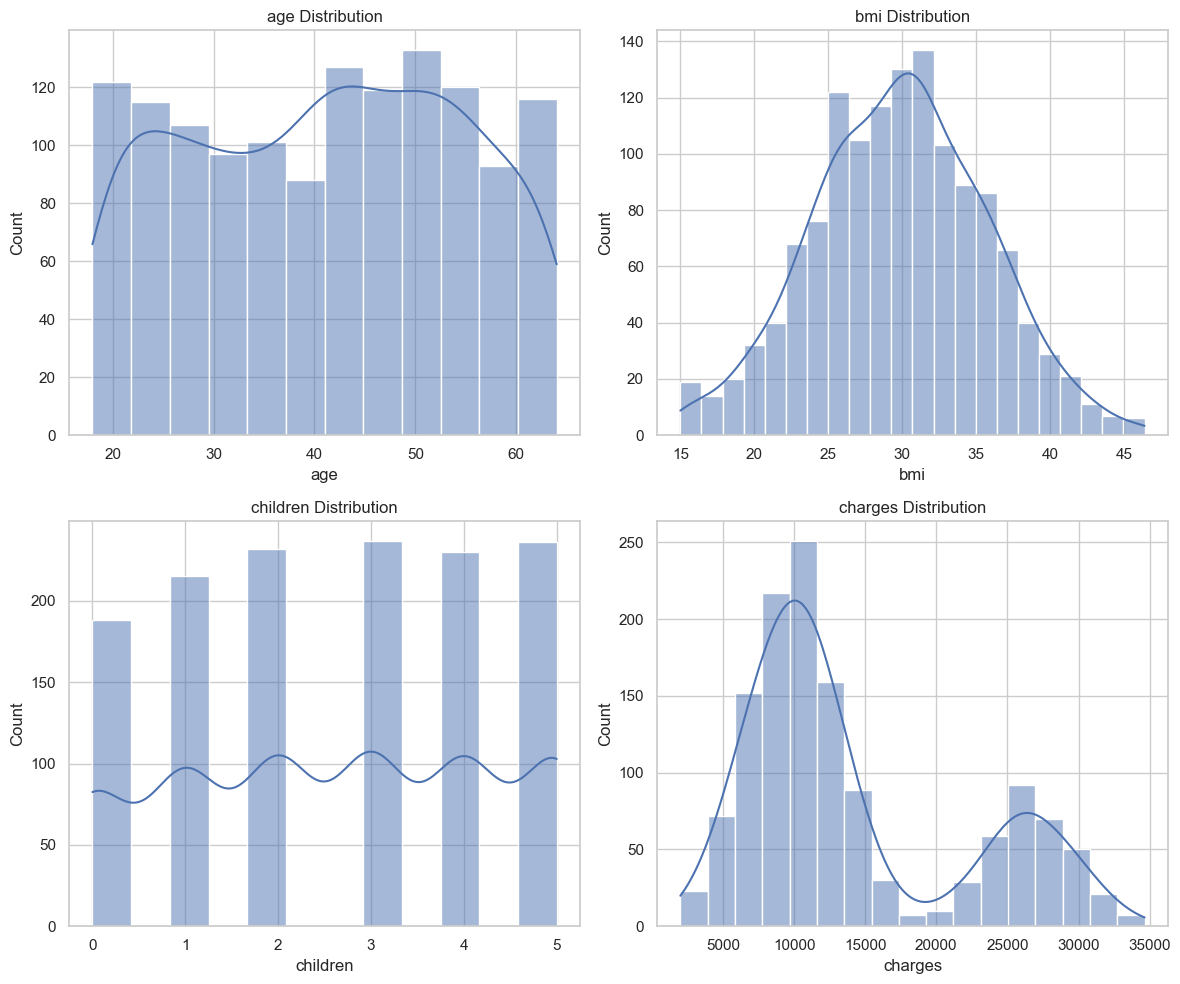

In [7]:
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i//2][i%2])
    axes[i//2][i%2].set_title(f"{col} Distribution")

plt.tight_layout()
plt.show()

In [8]:
df[num_cols].skew()

age        -0.051487
bmi        -0.005437
children   -0.066985
charges     0.880855
dtype: float64

## 7. Boxplots for Numerical Features

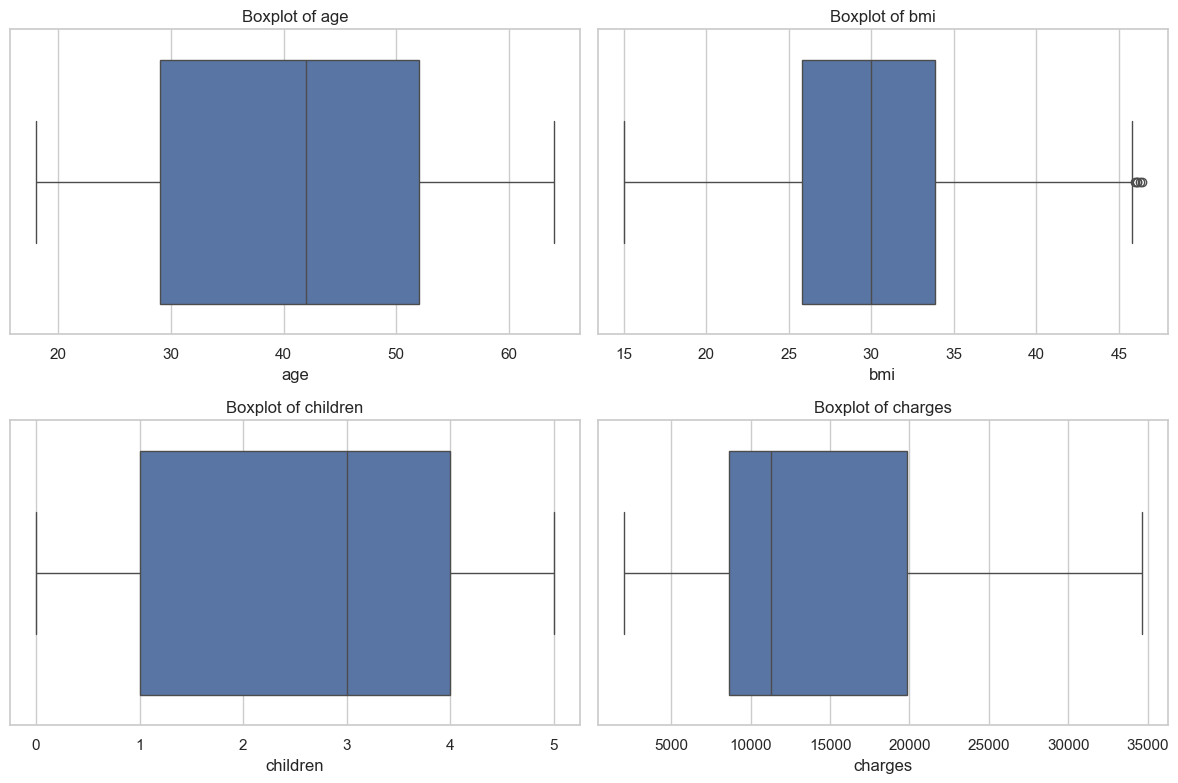

In [9]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

## 8. Categorical Feature Distributions

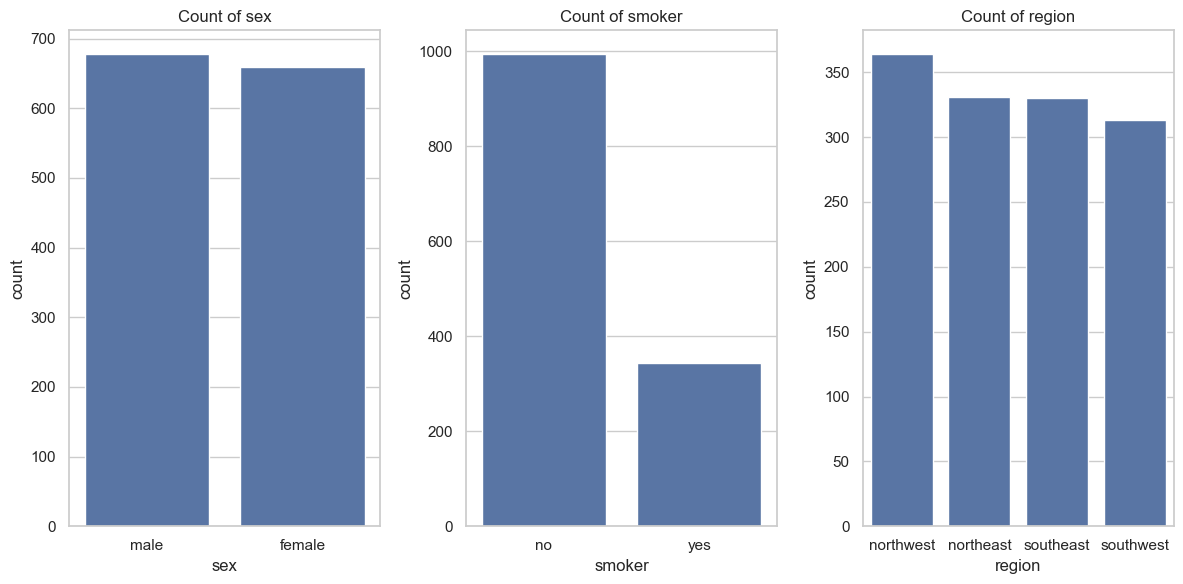

In [10]:
cat_cols = ["sex", "smoker", "region"]

plt.figure(figsize=(12, 6))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")

plt.tight_layout()
plt.show()

## 9. Correlation Heatmap

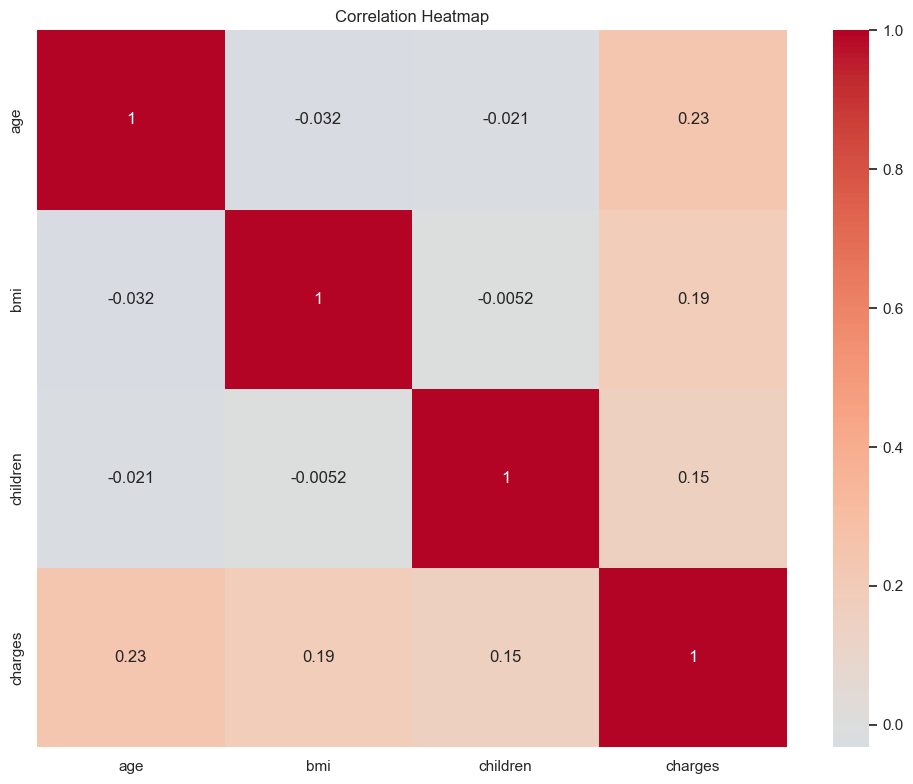

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 10. Encode Categorical Variables

In [12]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,56,26.5,4,11494.84,True,False,True,False,False
1,46,28.8,5,26785.00,False,True,False,False,False
2,32,25.4,3,2000.00,True,False,True,False,False
3,60,30.2,4,16809.62,True,False,False,True,False
4,25,26.3,2,22725.84,True,True,False,True,False


## 11. Relationship Between Smoker Status and Charges

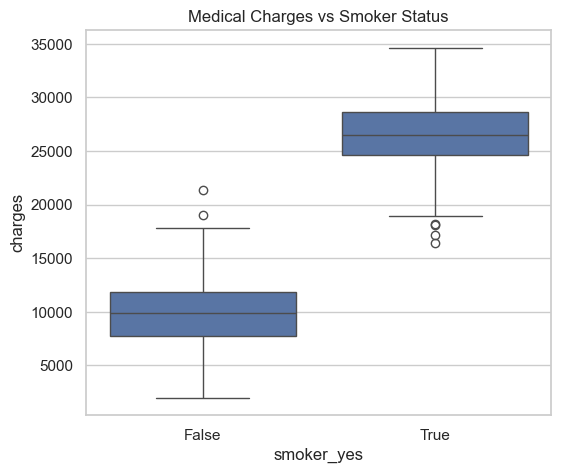

In [13]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker_yes', y='charges', data=df)
plt.title("Medical Charges vs Smoker Status")
plt.show()

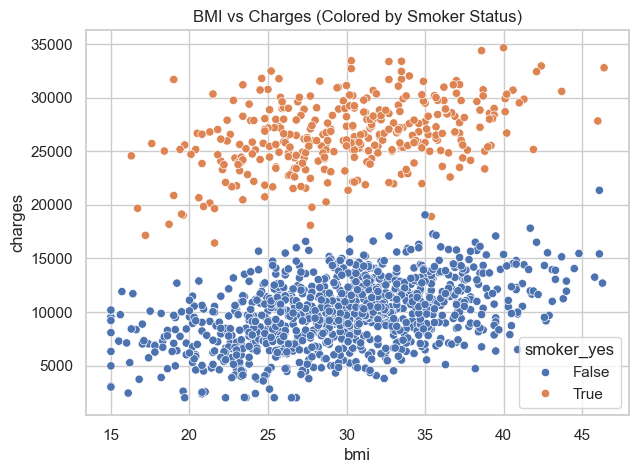

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker_yes')
plt.title("BMI vs Charges (Colored by Smoker Status)")
plt.show()

## 12. T-test: Charges for Smokers vs Non-Smokers

In [15]:
smokers = df[df['smoker_yes'] == True]['charges']
nonsmokers = df[df['smoker_yes'] == False]['charges']

t_stat, p_val = stats.ttest_ind(smokers, nonsmokers, equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_val)

T-statistic: 84.77445030881127
P-value: 0.0


## 13. Chi-square Test: Sex vs Smoker Status

In [16]:
cont_table = pd.crosstab(df['sex_male'], df['smoker_yes'])
chi_stat, p, dof, exp = stats.chi2_contingency(cont_table)

print("Chi-square statistic:", chi_stat)
print("Degrees of freedom:", dof)
print("P-value:", p)

Chi-square statistic: 1.049068465146435
Degrees of freedom: 1
P-value: 0.3057217252648403
